In [1]:
def pq2tfmatrix(pq):
  import meshcat.transformations as tf
  import numpy as np
  """
  Convert a pq to a transformation matrix
  :param pq: [position, quaternion]
  :return: transformation matrix
  """
  p = pq[:3]
  q = pq[3:]
  q.insert(0, q.pop())
  return tf.quaternion_matrix(q) + np.array([[0, 0, 0, p[0]],
                                             [0, 0, 0, p[1]],
                                             [0, 0, 0, p[2]],
                                             [0, 0, 0, 0]])
    
def robotInit(numLinks, resource_path, displayInitJson, vis):
  import meshcat.geometry as g
  import numpy as np
  robot = vis['robot']
  partInitConfig = displayInitJson['part_init_config']
  for i in range(numLinks):
    robot[str(i)].set_transform(pq2tfmatrix(partInitConfig[i]))

  geometryPool = displayInitJson['geometry_pool']
  for i in range(len(geometryPool)):
    geometry = geometryPool[i]
    meshcatGeo = robot[str(geometry['part_id'])][str(geometry['geometry_id'])]
    meshcatGeo.set_transform(np.array(geometry['init_pm']).reshape(4, 4))
    if i % 2 == 1: 
      material = g.MeshPhongMaterial(color=0x0660FF)
    else:
      material = g.MeshPhongMaterial(color=0xD4D4D4)
    if i == 0:
      material = g.MeshPhongMaterial(color=0x755338)
    if(geometry['shape_type'] == 'box'):
      meshcatGeo.set_object(g.Box([geometry['length'], geometry['width'], geometry['height']]), material=material)
    elif(geometry['shape_type'] == 'capsule'):
      meshcatGeo.set_object(g.Cylinder(geometry['size'][0], geometry['size'][1]), material=material)
    elif(geometry['shape_type'] == 'sphere'):
      meshcatGeo.set_object(g.Sphere(geometry['radius']), material=material)
    elif(geometry['shape_type'] == 'mesh'):
      ext = geometry['resource_path'].split('.')[-1]
      if ext == 'stl':
        meshcatGeo.set_object(g.StlMeshGeometry.from_file(
          resource_path, geometry['resource_path']), material=material)
      elif ext == 'obj':
        meshcatGeo.set_object(g.ObjMeshGeometry.from_file(
          resource_path + geometry['resource_path']), material=material)
      else:
        print("Unknown mesh file type", ext)

def setRobotPq(numLinks, frame, pqs):
  robot = frame['robot']
  for i in range(numLinks):
    robot[str(i)].set_transform(pq2tfmatrix(pqs[i]))

def binarySearch(timeIndices, time):
  import math
  """
  Binary search to find the index of the closest time
  :param timeIndices: list of time indices
  :param time: target time
  :return: index of the closest time index
  """
  low = 0
  high = len(timeIndices) - 1
  while low <= high:
    mid = (low + high) // 2
    if math.isclose(timeIndices[mid], time):
      return mid
    if timeIndices[mid] < time:
      low = mid + 1
    else:
      high = mid - 1

  return min(int(low), len(timeIndices) - 1)

def animateRobotByRecords(numLinks, records, frameRate, vis):
  from meshcat.animation import Animation
  partpq = records['partpq']
  timeIndices = records['timeindex']
  anim = Animation()
  anim.default_framerate = frameRate

  minTime = 0
  maxTime = timeIndices[-1]
  totalFrameNumber = int((maxTime - minTime) * anim.default_framerate)

  for i in range(totalFrameNumber):
    currentTime = minTime + i / anim.default_framerate
    currentIdx = binarySearch(timeIndices, currentTime)
    with anim.at_frame(vis, i) as frame:
      setRobotPq(numLinks, frame, partpq[currentIdx])

  vis.set_animation(anim)

def getFreeFallZAxis(min, max, records, frameRate):
  import numpy as np
  partpq = records['partPq']
  timeIndices = records['timeIndex']
  totalFrameNumber = int((max - min) * frameRate)
  result = np.zeros([2, totalFrameNumber])

  for i in range(totalFrameNumber):
    currentTime = min + i / frameRate
    currentIdx = binarySearch(timeIndices, currentTime)
    result[0][i] = timeIndices[currentIdx]
    # print("index", currentIdx)
    # print("time interested", currentTime)
    # print("time selected", timeIndices[currentIdx])
    result[1][i] = partpq[currentIdx][1][2]
  return result

In [2]:
import sys
sys.path.append("D:/Documents/code/sire/install/python/release")
import sire

In [3]:
from os.path import abspath
import os
cs = sire.ControlServer.instance()
configPath = abspath(os.getcwd()) + "/sire_ball_free_fall_withIPE.xml"
print(configPath)
sire.fromXmlFile(cs, configPath)
cs.init()

d:\code\sire\demo\demo_paper\sire\init_penetration_elimination/sire_ball_free_fall_withIPE.xml


In [4]:
simulator = sire.simulator(cs)
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  simulator.step(1, False)

In [5]:
result = simulator.recordsToJson()

In [6]:
from os.path import abspath
import os
cs = sire.ControlServer.instance()
configPath = abspath(os.getcwd()) + "/sire_ball_free_fall_withoutIPE.xml"
print(configPath)
sire.fromXmlFile(cs, configPath)
cs.init()

d:\code\sire\demo\demo_paper\sire\init_penetration_elimination/sire_ball_free_fall_withoutIPE.xml


In [7]:
simulator = sire.simulator(cs)
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  simulator.step(1, False)
result1 = simulator.recordsToJson()

In [8]:
import matplotlib.pyplot as plt
import scienceplots

frameRate = 40
minTime = 0
maxTime = 1.8
x1, y1 = getFreeFallZAxis(minTime, maxTime, result, frameRate)
x2, y2 = getFreeFallZAxis(minTime, maxTime, result1, frameRate)
y1 = y1 - 1
y2 = y2 - 1

frameRate = 20000
minTime = 0.9
maxTime = 0.906
x3, y3 = getFreeFallZAxis(minTime, maxTime, result, frameRate)
x4, y4 = getFreeFallZAxis(minTime, maxTime, result1, frameRate)
y3 = y3 - 1
y4 = y4 - 1

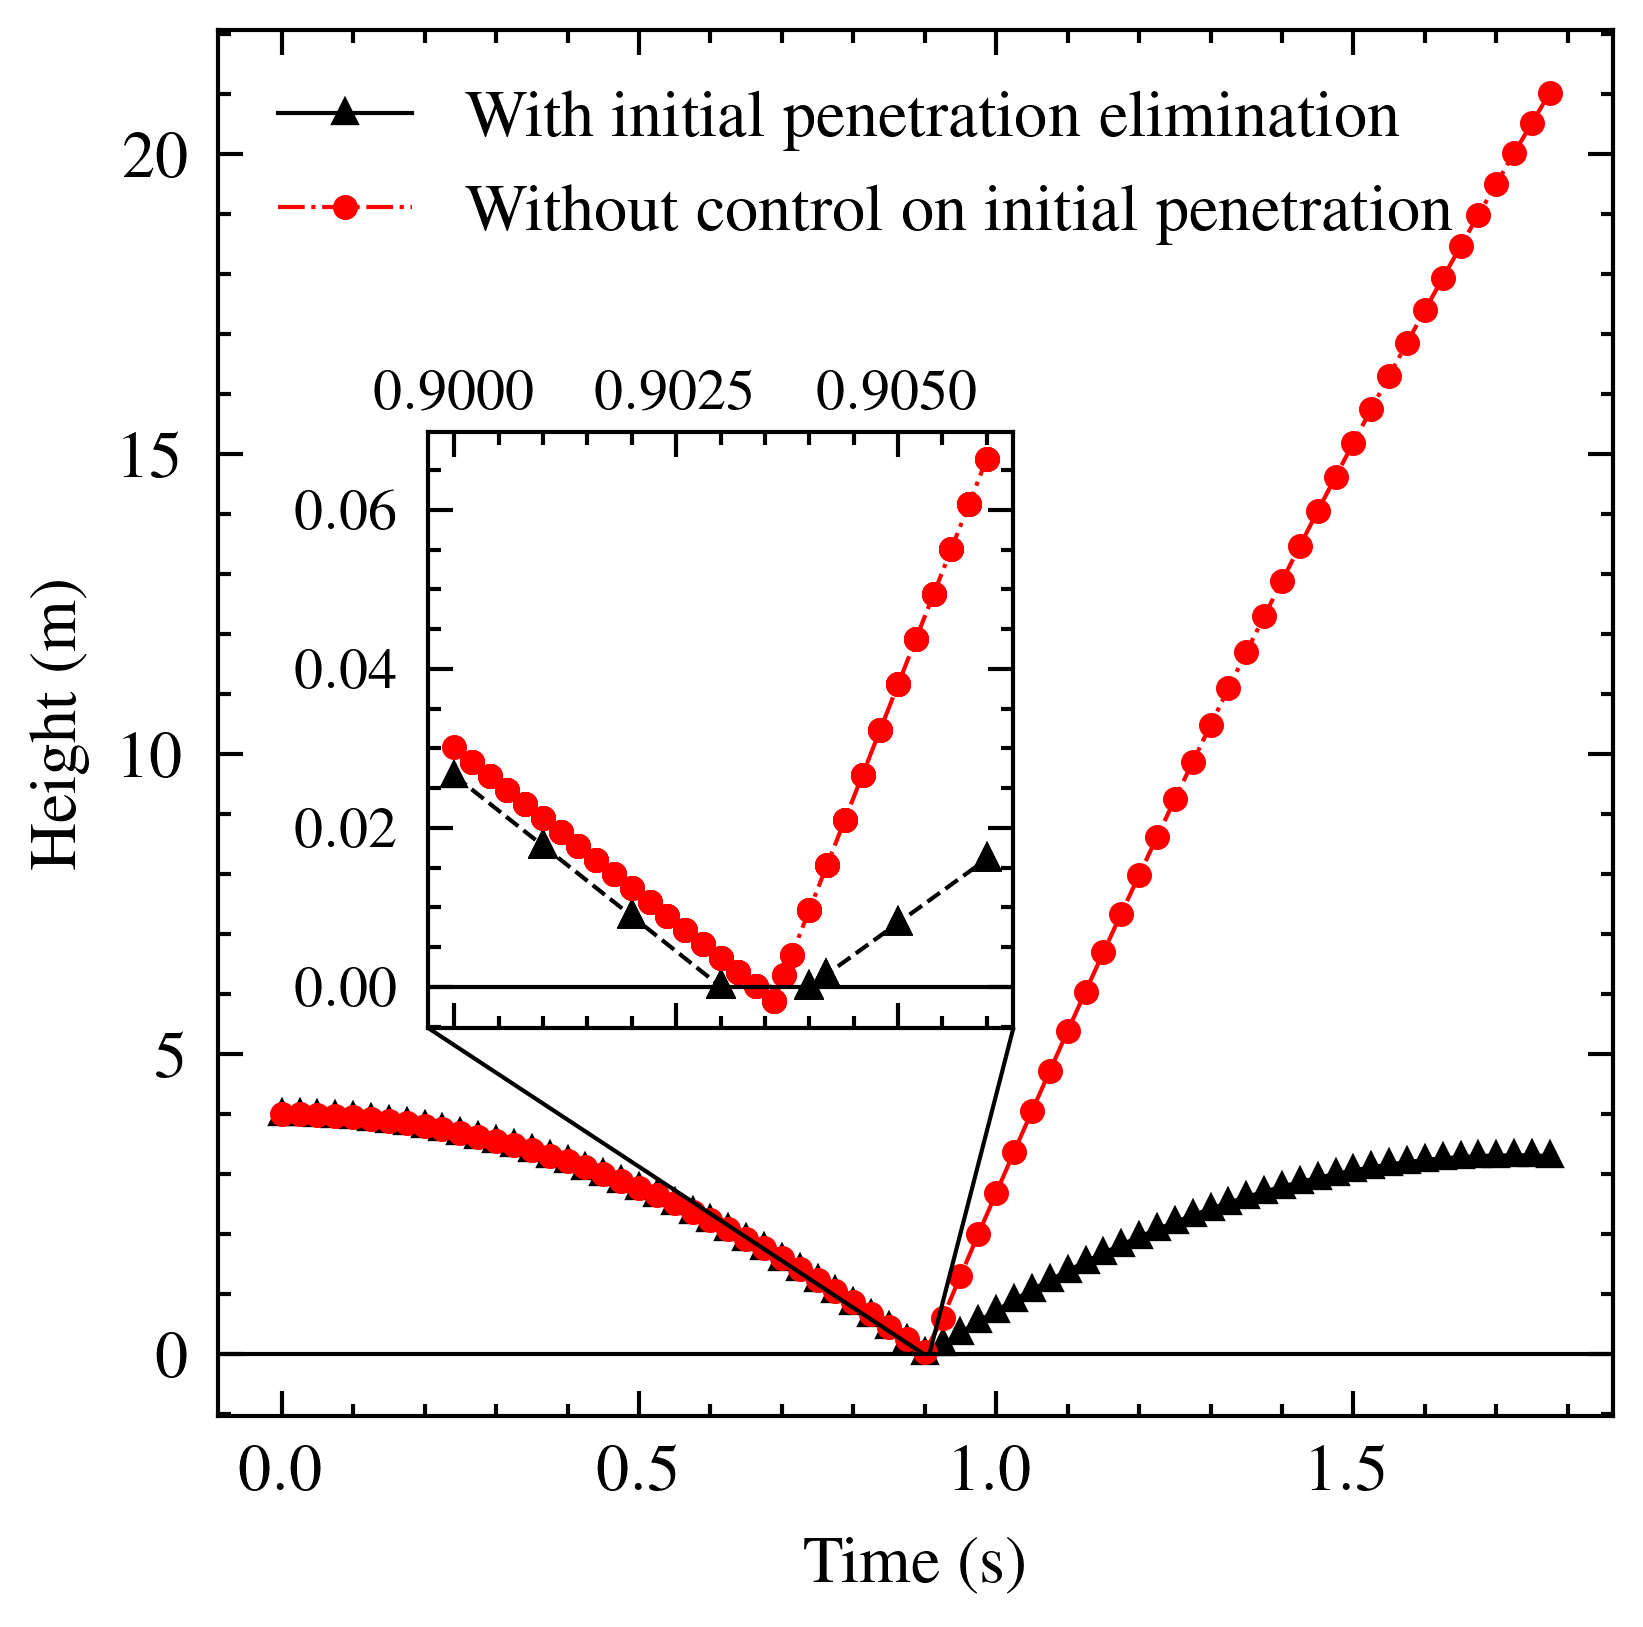

In [32]:
with plt.style.context(['science','ieee']):
  # fig, ax = plt.subplots(figsize=(4, 4))
  fig, ax = plt.subplots(figsize=(3, 3))
  ax.plot(x1, y1, marker='^', markersize=2, linewidth=0.5, linestyle='-')
  ax.plot(x2, y2, marker='o', markersize=2, linewidth=0.5, linestyle='-.')
  ax.legend(['With initial penetration elimination', 'Without control on initial penetration'], loc='upper left')
  ax.axhline(y=0, linewidth=0.5)
  ax.set_ylabel(r'Height (m)')
  ax.set_xlabel(r'Time (s)', fontsize=8)
  from mpl_toolkits.axes_grid1.inset_locator import inset_axes
  from mpl_toolkits.axes_grid1.inset_locator import mark_inset
  axins = ax.inset_axes((0.15, 0.28, 0.42, 0.43))
  axins.plot(x3, y3, marker='^', markersize=2, linewidth=0.5, linestyle='--')
  axins.plot(x4, y4, marker='o', markersize=2, linewidth=0.5, linestyle='-.')
  axins.tick_params(axis='x', bottom=True, top=True, labelbottom=False, labeltop=True, labelsize=7, pad=1)
  axins.tick_params(axis='y', labelsize=7)
  axins.axhline(y=0, linewidth=0.5)
  mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec='k', lw=0.5)
  plt.savefig("D:/papers/sire_contact_model/res/initial_penetration_elimination.pdf", format="pdf", dpi=600, bbox_inches='tight')
  plt.show()
  plt.close()